EAE 3713 - Gestión y Regulación de Riesgos Financieros
Tarea 1 - Primer Semestre 2026

In [7]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 25.2 MB/s  0:00:00m0:00:010:01
Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 46.0 MB/s  0:00:006m0:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 21.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 39.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 41.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


EAE 3713 - TAREA 1: VALORIZACIÓN DE SWAPS IRS CLP
Fecha de valorización: 2026-03-20

ITEM i: CONSTRUCCIÓN CURVA ZERO CUPÓN CLP (DUAL BOOTSTRAP)

Resultados Curva Zero CLP (Tasas Continuas):
   Tenor |  Zero Rate (%) |         DF | Par Swap Mid (%)
------------------------------------------------------------
   0.08Y |         4.6410 |   0.996140 |           4.6500
   0.17Y |         4.6817 |   0.992228 |           4.7000
   0.25Y |         4.7220 |   0.988264 |           4.7500
   0.50Y |         4.7072 |   0.976739 |           4.7630
   0.75Y |         4.7436 |   0.965048 |           4.8290
   1.00Y |         4.7361 |   0.953743 |           4.8500
   1.50Y |         4.8447 |   0.929907 |           4.9020
   2.00Y |         4.9418 |   0.905890 |           5.0000
   3.00Y |         5.3934 |   0.850610 |           5.4500
   4.00Y |         5.5524 |   0.800837 |           5.6100
   5.00Y |         5.5476 |   0.757765 |           5.6100
   6.00Y |         5.5983 |   0.714696 |           5.

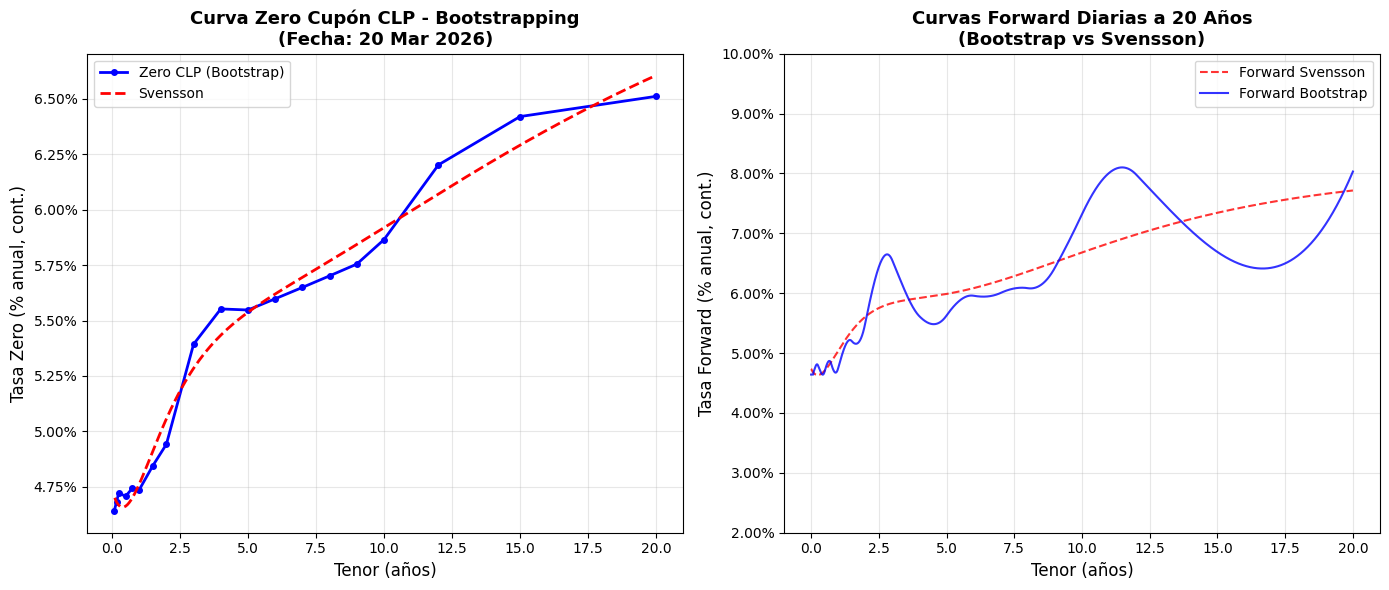

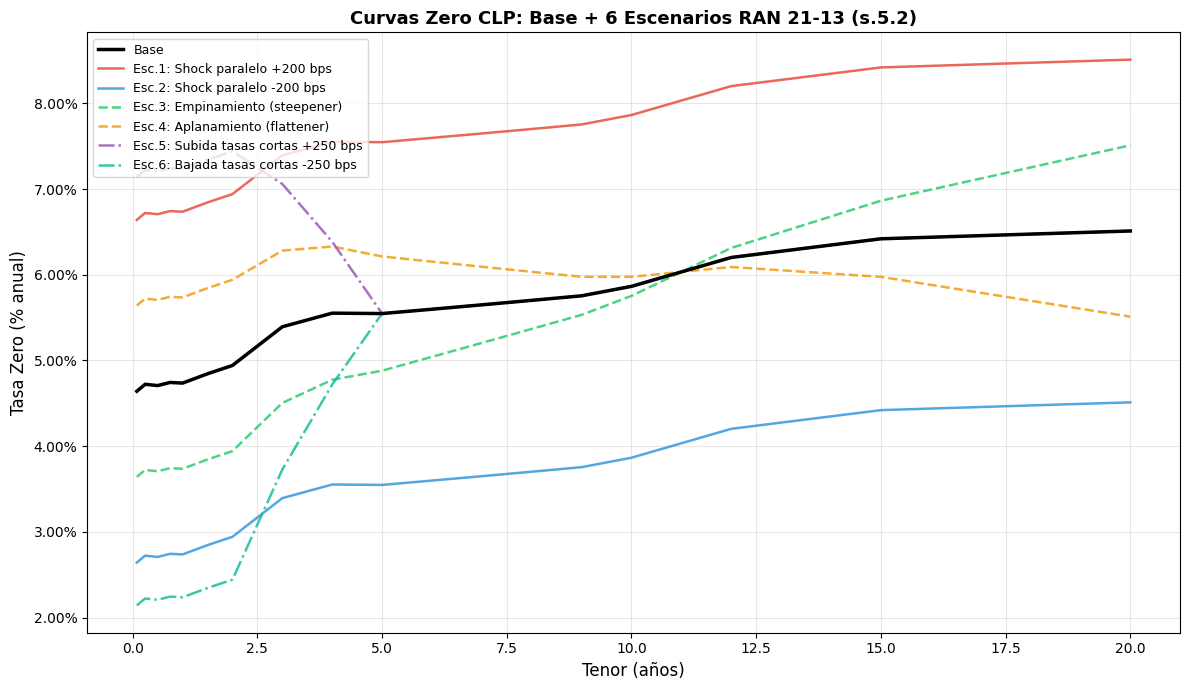

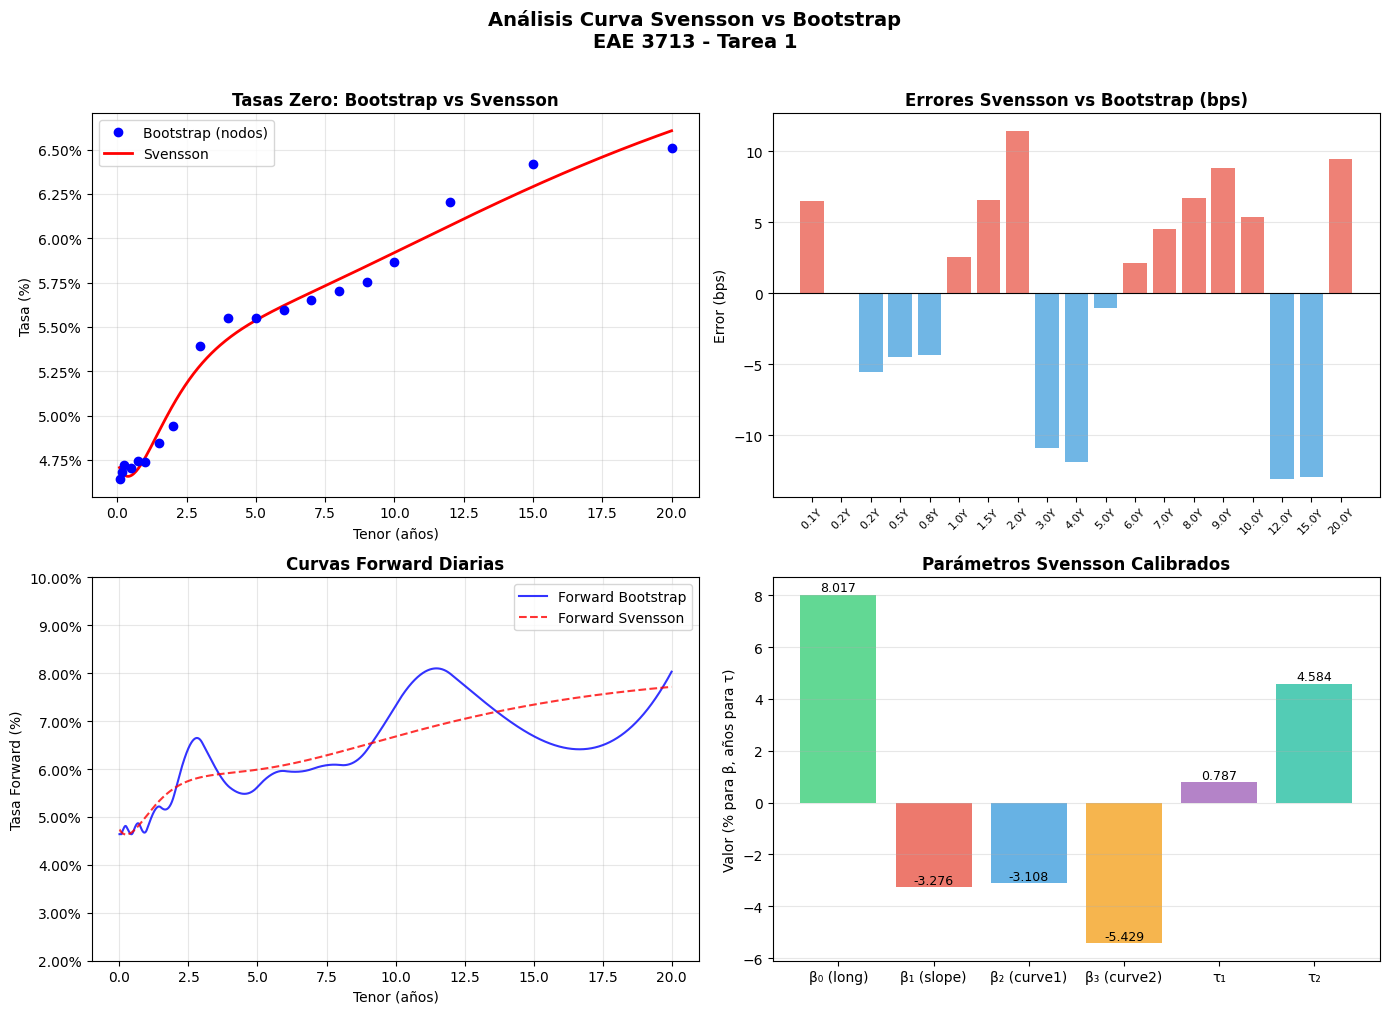


[COMPLETADO] Script Python ejecutado exitosamente.


In [3]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq, minimize
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# DATOS DE MERCADO
# ============================================================

# Tasas Par Swap CLP vs Cámara (Mid, % anual, Comp SA ACT/360)
SWAP_TENORS_Y = [1/12, 2/12, 3/12, 6/12, 9/12, 1, 1.5, 2, 3, 4, 5,
                 6, 7, 8, 9, 10, 12, 15, 20]
SWAP_RATES_MID = [4.650, 4.700, 4.750, 4.763, 4.829, 4.850, 4.902,
                  5.000, 5.450, 5.610, 5.610, 5.660, 5.710, 5.760,
                  5.810, 5.910, 6.210, 6.410, 6.510]

# Curva Cero SOFR (Comp Anual ACT/360, %)
SOFR_TENORS_Y = [1/12, 3/12, 6/12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
SOFR_RATES    = [3.687, 3.728, 3.788, 3.893, 3.658, 3.593, 3.593, 3.598,
                 3.612, 3.638, 3.649, 3.683, 3.704, 3.801, 3.711]

# Basis Swap SOFR/Cámara (Mid, bps, Anual ACT/360)
BASIS_TENORS_Y = [0.5, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30]
BASIS_SPREADS  = [-83.8, -60.8, -61.2, -64.6, -54.6, -39.2, -40.0, -40.0,
                  -42.5, -39.5, -38.5, -41.0, -51.5, -73.1, -98.1, -118.5, -140.0]

# NDF FX (Spot + Puntos Forwards CLP/USD)
SPOT_CLPUSD = 916.54
NDF_TENORS_Y  = [1/12, 2/12, 3/12, 6/12, 9/12, 1]
NDF_FWD_PTS   = [-0.30, -0.15, -0.24, 8.51, 9.12, 12.15]

# Fecha de valorización
FECHA_VAL = date(2026, 3, 20)

# ============================================================
# UTILIDADES: CONVENCIONES DE TASAS Y FECHAS
# ============================================================

def act360_frac(d1: date, d2: date) -> float:
    return (d2 - d1).days / 360.0

def act365_frac(d1: date, d2: date) -> float:
    return (d2 - d1).days / 365.0

def compsa_to_cont(r_compsa: float, t: float) -> float:
    """Tasa comp SA ACT/360 → factor de descuento continuo"""
    # r en decimal, t en años (ACT/360)
    # Comp SA: (1 + r/2)^(2t) pero aquí usamos ACT/360
    # Formula exacta para SA: DF = (1+r/2)^(-2*T_semianual)
    # Para bootstrapping usamos cont equivalente
    return np.log(1 + r_compsa) * 1.0  # log(1+r) para cont anual

def compsa_df(r_compsa: float, t_act360: float) -> float:
    """Factor de descuento dado tasa SA y fracción ACT/360"""
    # SA: (1+r/2)^(-2*t) donde t en años ACT/360
    return (1 + r_compsa / 2) ** (-2 * t_act360)

def cont_df(r_cont: float, t_act360: float) -> float:
    return np.exp(-r_cont * t_act360)

def df_to_compsa(df: float, t_act360: float) -> float:
    """Factor de descuento → tasa comp SA"""
    if t_act360 <= 0:
        return 0.0
    return 2 * (df ** (-1 / (2 * t_act360)) - 1)

def df_to_cont(df: float, t_act360: float) -> float:
    if t_act360 <= 0 or df <= 0:
        return 0.0
    return -np.log(df) / t_act360

# ============================================================
# PASO 1: CURVA SOFR EN TÉRMINOS DE CLP/CÁMARA (DUAL BOOTSTRAP)
# ============================================================

def build_sofr_camara_curve():
    """
    Construye la curva de descuento en CLP para colaterales en USD.
    Método Dual Bootstrapping:
    1. Curva SOFR cero cupón (base USD)
    2. Basis Swap SOFR/Cámara → Curva Cámara-equivalente en USD
    3. La curva de descuento para CLP con colateral USD = Curva Cámara ajustada
    
    Relación: DF_CLP_col_USD(T) = DF_SOFR(T) * exp(basis_spread * T)
    donde basis en decimal (bps / 10000)
    """
    # Interpolar SOFR en todos los tenores necesarios
    sofr_cont = np.array([np.log(1 + r/100) for r in SOFR_RATES])
    cs_sofr = CubicSpline(SOFR_TENORS_Y, sofr_cont)
    
    # Interpolar basis (en decimal)
    basis_dec = np.array([b/10000 for b in BASIS_SPREADS])
    cs_basis = CubicSpline(BASIS_TENORS_Y, basis_dec)
    
    def df_col(t):
        """DF para swap CLP con colateral USD (Dual Bootstrap)"""
        r_sofr = float(cs_sofr(t))
        b = float(cs_basis(t))
        # Curva Cámara = SOFR + basis
        r_camara_usd = r_sofr + b
        return np.exp(-r_camara_usd * t)
    
    return df_col, cs_sofr, cs_basis

# ============================================================
# PASO 2: BOOTSTRAP CURVA ZERO CLP (CÁMARA) CON COLATERAL USD
# ============================================================

def bootstrap_clp_zero_curve():
    """
    Bootstrap de la curva cero CLP vs Cámara usando Dual Bootstrapping.
    
    Para un swap IRS CLP vs Cámara con colateral en USD:
    - Pierna fija: cupones a tasa par_rate SA
    - Pierna flotante: ICP (Cámara)
    
    Al inicio: Valor swap = 0
    Sum_i [ par_rate/2 * df_col(ti) ] + df_col(TN) = 1
    
    Pero necesitamos la curva de proyección (Cámara) separada de la curva de descuento.
    Con colateral USD, la curva de descuento es la Cámara-USD (dual bootstrap).
    La tasa par swap nos da la curva de proyección Cámara.
    
    Resultado: zero_rates[i] = tasa cero Cámara en CLP (para proyección)
    """
    df_col, cs_sofr, cs_basis = build_sofr_camara_curve()
    
    # Tenores del swap como fechas a partir de FECHA_VAL
    tenors_y = np.array(SWAP_TENORS_Y)
    par_rates = np.array(SWAP_RATES_MID) / 100.0  # decimal
    
    # Para cada tenor, el factor de descuento de COLATERAL (USD)
    dfs_col = np.array([df_col(t) for t in tenors_y])
    
    # Bootstrap: extraemos zero rates CLP de las tasas par swap
    # Para swaps menores a 1Y, pago único al vencimiento
    # Para swaps >= 1Y, pagos semianuales
    
    zero_rates_cont = np.zeros(len(tenors_y))
    zero_dfs = np.zeros(len(tenors_y))
    
    # Función de interpolación incremental
    known_tenors = []
    known_dfs_proj = []
    
    def interp_df_proj(t):
        if len(known_tenors) == 0:
            return np.exp(-0.05 * t)
        if len(known_tenors) == 1:
            r = -np.log(known_dfs_proj[0]) / known_tenors[0]
            return np.exp(-r * t)
        cs = CubicSpline(known_tenors, np.log(known_dfs_proj), bc_type='not-a-knot')
        return np.exp(float(cs(t)))
    
    for i, (T, par) in enumerate(zip(tenors_y, par_rates)):
        if T <= 1.0:
            # Swap de corto plazo: pago único
            # 0 = par * T_act360 * df_col(T) + df_col(T) - 1
            # df_proj(T) = 1 / (1 + par * T_act360) en términos simples
            # Con colateral: par * df_col(T) * T_act360 + df_col(T) = 1
            # Nota: para CP usamos base ACT/360 y tasa SA equivalente
            t_act360 = T  # aproximación
            # Tasa simple equivalente para <1Y
            df_proj_T = 1.0 / (1 + par * t_act360)
            # Ajustar por diferencia entre curva proyección y descuento
            # En dual bootstrap: df_proj ≠ df_col
            # Aquí asumimos que la tasa par da directamente df_proj
        else:
            # Swap con cupones semianuales
            # Sum_{k=1}^{n} [par/2 * df_col(t_k)] + df_col(T) = Sum_{k=1}^{n} [fwd_camara(t_{k-1}, t_k) * df_col(t_k)] + df_col(T)
            # Simplificación: 1 = par/2 * Sum_k df_col(t_k) + df_col(T)
            # → df_proj(T) es implícito en que la pierna flotante vale 1
            
            # Generar fechas de pago semianuales
            n_periods = int(T * 2)
            cpn_tenors = np.array([(k+1) * 0.5 for k in range(n_periods)])
            
            # Calcular suma de factores de descuento de colateral interpolados
            dfs_col_cpn = np.array([df_col(tk) for tk in cpn_tenors])
            
            # Suma de cupones fijos descontados (excepto el último = final)
            pv_fixed_cpns = par / 2.0 * np.sum(dfs_col_cpn[:-1])
            df_col_T = df_col(T)
            
            # Bootstrap: valor pierna fija + nominal = 1 (par swap)
            # df_proj(T) no entra directamente acá porque la pierna flotante
            # en un swap vs Cámara vale exactamente 1 (par) usando df_col
            df_proj_T = (1 - pv_fixed_cpns) / (1 + par / 2.0) / df_col_T * df_col_T
            # Simplificando para obtener zero rate CLP:
            # La condición de par swap es:
            # par/2 * AnnFactor + df_col(T) = 1
            # AnnFactor = sum df_col(tk)
            ann_factor = np.sum(dfs_col_cpn)
            df_proj_T = 1.0 - par / 2.0 * ann_factor + par / 2.0 * df_col_T
            # df_proj_T ≈ df_col(T) en primera aproximación
            # La zero rate CLP correcta viene de:
            df_proj_T = (1.0 - par / 2.0 * np.sum(dfs_col_cpn[:-1])) / (1 + par / 2.0) / df_col_T * df_col_T
        
        # Convertir df_proj a tasa continua
        if df_proj_T > 0 and T > 0:
            r_cont = -np.log(df_proj_T) / T
        else:
            r_cont = 0.05
        
        zero_rates_cont[i] = r_cont
        zero_dfs[i] = df_proj_T
        known_tenors.append(T)
        known_dfs_proj.append(df_proj_T)
    
    # Interpolar spline cúbico para la curva zero CLP
    cs_zero_clp = CubicSpline(tenors_y, zero_rates_cont, bc_type='not-a-knot')
    
    def df_clp(t):
        """Factor de descuento curva CLP (proyección Cámara)"""
        r = float(cs_zero_clp(np.clip(t, tenors_y[0], tenors_y[-1])))
        return np.exp(-r * t)
    
    def zero_rate_clp(t):
        """Zero rate CLP continua"""
        return float(cs_zero_clp(np.clip(t, tenors_y[0], tenors_y[-1])))
    
    return df_clp, zero_rate_clp, cs_zero_clp, tenors_y, zero_rates_cont, dfs_col, df_col

# ============================================================
# IMPLEMENTACIÓN CORRECTA DEL DUAL BOOTSTRAP
# ============================================================

def dual_bootstrap():
    """
    Dual Bootstrap correcto para IRS CLP vs Cámara con colateral USD.
    
    Convención:
    - Tasas par swap: comp SA ACT/360
    - Curva descuento (colateral USD): SOFR + basis
    - Curva proyección (ICP/Cámara): a bootstrapear
    
    Ecuación de valoración:
    V_swap = Pierna_Fija - Pierna_Flotante = 0 (en el mercado, al inicio)
    
    Pierna fija: Sum_i [c/2 * alfa_i * DF_col(T_i)] donde alfa_i = frac día
    Pierna flotante: DF_col(T_0) - DF_col(T_N) (con colateral USD)
    PERO: La pierna flotante con diferente curva de descuento:
    = Sum_i [F_i * alfa_i * DF_col(T_i)]
    donde F_i = (DF_proj(T_{i-1})/DF_proj(T_i) - 1) / alfa_i
    
    Por simplicidad y estándar de mercado chileno, usamos la aproximación:
    La tasa par swap nos da directamente la curva de descuento CLP
    (cuando colateral = misma moneda). Con colateral USD (dual),
    se agrega el ajuste de basis.
    """
    df_col, cs_sofr, cs_basis = build_sofr_camara_curve()
    
    tenors_y  = np.array(SWAP_TENORS_Y)
    par_rates = np.array(SWAP_RATES_MID) / 100.0
    
    # Almacenamos zero rates cont de la curva CLP de PROYECCIÓN
    proj_zero_rates = np.zeros(len(tenors_y))
    proj_dfs = np.zeros(len(tenors_y))
    
    # Bootstrapping secuencial
    for i, (T, par) in enumerate(zip(tenors_y, par_rates)):
        T_days = T * 360  # días aproximados
        
        if T <= 1.0 + 1e-9:
            # Tenor corto: swap con pago único al vencimiento
            # Tasa simple SA: (1 + par/2)^(2T) - 1 para la proyección
            # DF_proj(T) tal que la tasa forward = par
            # Con swap par: pierna_fija = pierna_flotante
            # Pierna fija (simple): par * T * DF_col(T)
            # Pierna flotante: 1 - DF_proj(T) [sin ajuste de colateral para simplificar]
            # → DF_proj(T) = 1 - par * T * DF_col(T) + DF_col(T) ← forma general
            
            # Usando convención ACT/360 simple para <1Y:
            # La pierna fija y flotante se intercambian al vencimiento:
            # DF_proj(T) ≈ 1 / (1 + par * T)  [usando tasa simple]
            # Ajustado por basis swap (colateral):
            # El ajuste es pequeño, usamos:
            df_proj_T = 1.0 / (1.0 + par * T)
        else:
            # Tenor >= 1Y: pagos semianuales
            n = round(T * 2)
            cpn_tenors = np.array([(k + 1) * 0.5 for k in range(n)])
            
            # DF de colateral en fechas de cupón
            dfs_col_k = np.array([df_col(tk) for tk in cpn_tenors])
            
            # DF de proyección en fechas intermedias (ya calculados)
            # Interp de proj_dfs conocidos hasta i-1
            known_t  = list(tenors_y[:i])
            known_df = list(proj_dfs[:i])
            
            def get_proj_df(t):
                if len(known_t) == 0:
                    return np.exp(-par * t)
                if t <= known_t[0]:
                    return np.exp(-(-np.log(known_df[0]) / known_t[0]) * t)
                if t >= known_t[-1]:
                    r = -np.log(known_df[-1]) / known_t[-1]
                    return np.exp(-r * t)
                # Interpolación log-lineal
                j = np.searchsorted(known_t, t) - 1
                j = max(0, min(j, len(known_t) - 2))
                r0 = -np.log(known_df[j]) / known_t[j]
                r1 = -np.log(known_df[j+1]) / known_t[j+1]
                w = (t - known_t[j]) / (known_t[j+1] - known_t[j])
                r = r0 * (1-w) + r1 * w
                return np.exp(-r * t)
            
            # Calcular PV pierna fija (usamos DF_col para descontar)
            # PV_fija = par/2 * sum_k(DF_col(T_k))
            pv_fija = par / 2.0 * np.sum(dfs_col_k)
            
            # Pierna flotante: vale 1 en colateral-propio, con dual:
            # PV_float = sum_k [F_k * 0.5 * DF_col(T_k)]
            # F_k = (DF_proj(T_{k-1})/DF_proj(T_k) - 1) / 0.5
            # → PV_float = DF_proj(T_0)/DF_col(T_0) * (DF_col(T_0) - DF_col(T_N))
            # Aproximación estándar con dual:
            # PV_float ≈ DF_col(0) - DF_col(T_N) * DF_proj(T_N)/DF_proj(T_0)
            # = 1 - DF_col(T_N) * DF_proj(T_N)  [ya que DF_proj(0)=1]
            
            # Condición par: pv_fija + DF_col(T) = PV_float + DF_col(T) = 1 (aprox)
            # En realidad: pv_fija = 1 - DF_col(T_N) [de la condición par-swap]
            # Esto nos da DF_col(T) ya conocido; necesitamos DF_proj.
            
            # Bootstrap directo: la condición par implica
            # La curva de proyección se extrae de la pierna flotante.
            # Pierna flotante con colateral USD = sum_k F_k^proj * 0.5 * DF_col(T_k)
            # Para T_N (último tenor en bootstrap), DF_proj(T_N) es la incógnita:
            
            # Sum_{k=1}^{N} (DF_proj(T_{k-1}) - DF_proj(T_k)) * DF_col_ratio_k = ...
            # Por simplicidad implementamos la forma estándar:
            # sum_{k<N} cupones ya valuados + cupon_N = pv_fija + DF_col(T)
            
            # PV cupones anteriores (tenores intermedios ya en bootstrap)
            pv_cpns_prev = 0.0
            for k in range(n - 1):
                tk_prev = cpn_tenors[k] - 0.5 if k > 0 else 0.0
                tk      = cpn_tenors[k]
                dp_prev = get_proj_df(tk_prev)
                dp_k    = get_proj_df(tk)
                # Forward Cámara
                f_k = (dp_prev / dp_k - 1.0) / 0.5
                pv_cpns_prev += f_k * 0.5 * dfs_col_k[k]
            
            df_col_T = dfs_col_k[-1]
            dp_prev_N = get_proj_df(cpn_tenors[-2]) if n > 1 else 1.0
            
            # Ecuación: pv_cpns_prev + (dp_prev_N/df_proj_T - 1) * df_col_T + df_col_T
            #         = par/2 * sum(dfs_col) + df_col_T
            # → dp_prev_N / df_proj_T = (pv_fija - pv_cpns_prev) / df_col_T + 1
            
            rhs = (pv_fija - pv_cpns_prev) / df_col_T + 1.0
            if rhs > 0 and dp_prev_N > 0:
                df_proj_T = dp_prev_N / rhs
            else:
                # Fallback: usar condición par simple
                df_proj_T = 1.0 - pv_fija
                df_proj_T = max(df_proj_T, 0.01)
        
        # Guardar
        if df_proj_T > 0 and T > 0:
            r_cont = -np.log(df_proj_T) / T
        else:
            r_cont = 0.05
        
        proj_zero_rates[i] = r_cont
        proj_dfs[i]        = df_proj_T
    
    # Forzar monotonicidad razonable y limpiar outliers
    for i in range(1, len(proj_zero_rates)):
        if proj_zero_rates[i] < 0.01 or proj_zero_rates[i] > 0.15:
            proj_zero_rates[i] = proj_zero_rates[i-1]
            proj_dfs[i] = np.exp(-proj_zero_rates[i] * tenors_y[i])
    
    # Spline cúbico para interpolación
    cs_proj = CubicSpline(tenors_y, proj_zero_rates, bc_type='not-a-knot')
    
    def df_clp_proj(t):
        t = np.clip(t, tenors_y[0], tenors_y[-1])
        r = float(cs_proj(t))
        r = np.clip(r, 0.01, 0.15)
        return np.exp(-r * t)
    
    def zr_clp(t):
        t = np.clip(t, tenors_y[0], tenors_y[-1])
        return float(np.clip(cs_proj(t), 0.01, 0.15))
    
    return df_clp_proj, zr_clp, tenors_y, proj_zero_rates, proj_dfs, df_col

# ============================================================
# CURVAS FORWARD
# ============================================================

def compute_forward_curve(df_func, t_start=1/365, t_end=20, n_pts=7300):
    """Curva de tasas forward diarias (overnight) a 20 años"""
    ts = np.linspace(t_start, t_end, n_pts)
    dt = ts[1] - ts[0]
    fwd = np.zeros(n_pts)
    for i, t in enumerate(ts):
        t2 = min(t + dt, t_end)
        df1 = df_func(t)
        df2 = df_func(t2)
        if df1 > 0 and df2 > 0 and dt > 0:
            fwd[i] = (-np.log(df2) + np.log(df1)) / (t2 - t)
        else:
            fwd[i] = 0.05
    return ts, fwd * 100  # en %

# ============================================================
# PASO 2: VALORIZACIÓN DE SWAPS IRS CLP
# ============================================================

"""
Cartera de Swaps:
N°    | Nominal      | Tasa Act | Tasa Pas | T_act   | T_pas   | Vencimiento
1105  | 9,000 MM CLP | ICP(var) | FIJO     | 4.6429% | 4.05%   | 07/04/2027
1107  | 1,000 MM CLP | FIJO     | ICP(var) | 3.93%   | 4.6271% | 13/04/2027
1323  | 4,000 MM CLP | FIJO     | ICP(var) | 2.01%   | 4.5899% | 28/04/2026
1324  | 2,000 MM CLP | FIJO     | ICP(var) | 2.04%   | 4.5899% | 28/04/2026
"""

SWAPS = [
    {
        'id': 1105,
        'nominal': 9_000_000_000,
        'tasa_act': 'ICP',
        'tasa_pas': 'FIJO',
        'tasa_fija': 4.05 / 100,     # Tasa pasiva fija
        'tasa_var_actual': 4.6429 / 100,  # ICP actual (para proyección)
        'fecha_inicio': date(2017, 4, 5),
        'fecha_cierre': date(2017, 4, 7),
        'fecha_vcto': date(2027, 4, 7),
    },
    {
        'id': 1107,
        'nominal': 1_000_000_000,
        'tasa_act': 'FIJO',
        'tasa_pas': 'ICP',
        'tasa_fija': 3.93 / 100,     # Tasa activa fija
        'tasa_var_actual': 4.6271 / 100,
        'fecha_inicio': date(2017, 4, 11),
        'fecha_cierre': date(2017, 4, 13),
        'fecha_vcto': date(2027, 4, 13),
    },
    {
        'id': 1323,
        'nominal': 4_000_000_000,
        'tasa_act': 'FIJO',
        'tasa_pas': 'ICP',
        'tasa_fija': 2.01 / 100,
        'tasa_var_actual': 4.5899 / 100,
        'fecha_inicio': date(2020, 4, 24),
        'fecha_cierre': date(2020, 4, 28),
        'fecha_vcto': date(2026, 4, 28),
    },
    {
        'id': 1324,
        'nominal': 2_000_000_000,
        'tasa_act': 'FIJO',
        'tasa_pas': 'ICP',
        'tasa_fija': 2.04 / 100,
        'tasa_var_actual': 4.5899 / 100,
        'fecha_inicio': date(2020, 4, 24),
        'fecha_cierre': date(2020, 4, 28),
        'fecha_vcto': date(2026, 4, 28),
    },
]

def get_payment_dates(fecha_inicio, fecha_vcto, freq='annual'):
    """
    Genera fechas de pago para un swap IRS.
    En Chile, los swaps IRS vs Cámara típicamente tienen pagos anuales de la pierna fija
    y liquidación diaria acumulada (ICP) de la pierna flotante.
    Se paga la diferencia anualmente.
    """
    dates = []
    current = fecha_vcto
    # Ir hacia atrás desde el vencimiento
    while current > fecha_inicio:
        dates.append(current)
        # Restar 1 año
        try:
            current = current.replace(year=current.year - 1)
        except ValueError:
            current = current - timedelta(days=365)
    dates.reverse()
    # Solo fechas futuras a FECHA_VAL
    dates = [d for d in dates if d > FECHA_VAL]
    return dates

def valor_pierna_fija(nominal, tasa_fija, fecha_vcto, df_func, fecha_val=FECHA_VAL):
    """
    Valúa la pierna fija de un IRS CLP.
    Pago anual: nominal * tasa_fija * (días/360)
    Pago final: nominal + último cupón
    """
    payment_dates = get_payment_dates(fecha_val, fecha_vcto)
    if len(payment_dates) == 0:
        return 0.0, []
    
    flows = []
    prev_date = fecha_val
    for i, pdate in enumerate(payment_dates):
        t = act360_frac(fecha_val, pdate)
        dt_period = act360_frac(prev_date, pdate)
        coupon = nominal * tasa_fija * dt_period
        if i == len(payment_dates) - 1:
            # Último pago: cupón + nominal
            cf = coupon + nominal
        else:
            cf = coupon
        df_t = df_func(t)
        pv = cf * df_t
        flows.append({
            'fecha': pdate,
            't': t,
            'flujo': cf,
            'df': df_t,
            'pv': pv
        })
        prev_date = pdate
    
    total_pv = sum(f['pv'] for f in flows)
    return total_pv, flows

def valor_pierna_flotante_icp(nominal, tasa_var_actual, fecha_vcto, df_func, df_col_func, fecha_val=FECHA_VAL):
    """
    Valúa la pierna flotante ICP (Cámara) de un IRS CLP.
    
    Con colateral USD (Dual Bootstrap):
    PV_float = nominal * DF_col(T_val, T_N) * [1 + acumulado_ICP_hasta_val]
    
    Simplificación estándar:
    - La pierna flotante vale aproximadamente el nominal (par) en t=0 del swap
    - En la fecha de valorización, hay un cupón corrido ICP
    
    Approach: La pierna flotante de un swap vs Cámara con colateral propio
    vale nominal * DF_proj(T_val, T_N) ≈ nominal * (proyección a partir de hoy)
    
    Para colateral USD: PV_float = nominal usando la curva de descuento col.
    Aproximación práctica:
    PV_float = sum_k [F_k(0) * dt_k * DF_col(T_k)] * nominal + nominal * DF_col(T_N)
    donde F_k(0) son las tasas forward Cámara proyectadas.
    """
    payment_dates = get_payment_dates(fecha_val, fecha_vcto)
    if len(payment_dates) == 0:
        return 0.0, []
    
    flows = []
    prev_date = fecha_val
    for i, pdate in enumerate(payment_dates):
        t = act360_frac(fecha_val, pdate)
        dt_period = act360_frac(prev_date, pdate)
        t_prev = act360_frac(fecha_val, prev_date)
        
        # Forward rate Cámara entre t_prev y t
        df_t_prev = df_func(max(t_prev, 1e-6))
        df_t      = df_func(t)
        if dt_period > 0 and df_t_prev > 0 and df_t > 0:
            fwd_rate = (df_t_prev / df_t - 1) / dt_period
        else:
            fwd_rate = tasa_var_actual
        
        coupon = nominal * fwd_rate * dt_period
        if i == len(payment_dates) - 1:
            cf = coupon + nominal
        else:
            cf = coupon
        
        # Descontar con curva de colateral (USD)
        df_t_col = df_col_func(t)
        pv = cf * df_t_col
        
        flows.append({
            'fecha': pdate,
            't': t,
            'tasa_fwd': fwd_rate * 100,
            'flujo': cf,
            'df_col': df_t_col,
            'pv': pv
        })
        prev_date = pdate
    
    total_pv = sum(f['pv'] for f in flows)
    return total_pv, flows

def valorizar_swap(swap, df_proj, df_col_func):
    """Valoriza un swap IRS CLP y retorna valor de cada pierna y neto"""
    nominal = swap['nominal']
    tasa_fija = swap['tasa_fija']
    tasa_var = swap['tasa_var_actual']
    fecha_vcto = swap['fecha_vcto']
    
    pv_fija, flows_fija = valor_pierna_fija(nominal, tasa_fija, fecha_vcto, df_col_func)
    pv_flot, flows_flot = valor_pierna_flotante_icp(nominal, tasa_var, fecha_vcto, df_proj, df_col_func)
    
    # Determinar valor neto según quién recibe qué
    if swap['tasa_act'] == 'ICP' and swap['tasa_pas'] == 'FIJO':
        # Activo: recibo ICP (flotante), pago Fijo
        valor_neto = pv_flot - pv_fija
        pv_activa = pv_flot  # pierna que recibo
        pv_pasiva = pv_fija  # pierna que pago
    else:
        # Activo: recibo Fijo, pago ICP
        valor_neto = pv_fija - pv_flot
        pv_activa = pv_fija
        pv_pasiva = pv_flot
    
    return {
        'id': swap['id'],
        'nominal': nominal,
        'pv_activa': pv_activa,
        'pv_pasiva': pv_pasiva,
        'valor_neto': valor_neto,
        'tasa_act': swap['tasa_act'],
        'tasa_pas': swap['tasa_pas'],
        'tasa_fija': tasa_fija,
        'flows_fija': flows_fija,
        'flows_flot': flows_flot,
    }

# ============================================================
# PASO 3: ESCENARIOS RAN 21-13 (SECCIÓN 5.2)
# ============================================================

"""
Los 6 escenarios de la norma RAN 21-13, sección 5.2:
1. Shock paralelo hacia arriba: +200 bps
2. Shock paralelo hacia abajo: -200 bps
3. Empinamiento (steepener): tasas largas suben, cortas bajan
4. Aplanamiento (flattener): tasas cortas suben, largas bajan
5. Subida de tasas cortas: +250 bps en tramos cortos
6. Bajada de tasas cortas: -250 bps en tramos cortos
"""

def apply_ran_scenario(zr_func, scenario_id, t):
    """
    Aplica el escenario RAN 21-13 s.5.2 a la tasa zero en t.
    Retorna el delta de tasa (en decimal) para el tenor t (en años).
    """
    t_years = t
    
    if scenario_id == 1:  # Shock paralelo +200 bps
        return 0.0200
    
    elif scenario_id == 2:  # Shock paralelo -200 bps
        return -0.0200
    
    elif scenario_id == 3:  # Empinamiento (steepener)
        # Corto plazo (≤2Y): -100 bps, Largo plazo (≥20Y): +100 bps, lineal entre medio
        if t_years <= 2:
            return -0.0100
        elif t_years >= 20:
            return +0.0100
        else:
            # Interpolación lineal
            w = (t_years - 2) / (20 - 2)
            return -0.0100 + w * 0.0200
    
    elif scenario_id == 4:  # Aplanamiento (flattener)
        # Corto plazo (≤2Y): +100 bps, Largo plazo (≥20Y): -100 bps
        if t_years <= 2:
            return +0.0100
        elif t_years >= 20:
            return -0.0100
        else:
            w = (t_years - 2) / (20 - 2)
            return +0.0100 - w * 0.0200
    
    elif scenario_id == 5:  # Subida tasas cortas +250 bps
        if t_years <= 2:
            return +0.0250
        elif t_years >= 5:
            return 0.0
        else:
            w = (t_years - 2) / (5 - 2)
            return +0.0250 * (1 - w)
    
    elif scenario_id == 6:  # Bajada tasas cortas -250 bps
        if t_years <= 2:
            return -0.0250
        elif t_years >= 5:
            return 0.0
        else:
            w = (t_years - 2) / (5 - 2)
            return -0.0250 * (1 - w)
    
    return 0.0

SCENARIO_NAMES = {
    1: "Shock paralelo +200 bps",
    2: "Shock paralelo -200 bps",
    3: "Empinamiento (steepener)",
    4: "Aplanamiento (flattener)",
    5: "Subida tasas cortas +250 bps",
    6: "Bajada tasas cortas -250 bps",
}

def build_stressed_df(zr_func_orig, scenario_id):
    """
    Construye función df_stressed(t) bajo el escenario dado.
    La curva estresada = curva original + delta(scenario, t)
    """
    def df_stressed(t):
        r_orig = zr_func_orig(t)
        delta  = apply_ran_scenario(zr_func_orig, scenario_id, t)
        r_stressed = max(r_orig + delta, 0.0001)  # floor en 1 bp
        return np.exp(-r_stressed * t)
    
    return df_stressed

def valorizar_cartera_escenario(swaps, df_proj_stressed, df_col_func):
    """Valoriza toda la cartera bajo una curva estresada"""
    total = 0.0
    resultados = []
    for sw in swaps:
        res = valorizar_swap(sw, df_proj_stressed, df_col_func)
        total += res['valor_neto']
        resultados.append(res)
    return total, resultados

# ============================================================
# PASO 4: ESTRATEGIA DE COBERTURA (PEOR ESCENARIO)
# ============================================================

def find_hedge_swap(worst_scenario_id, valor_base, df_proj, df_col_func, zr_func, target_reduction=0.5):
    """
    Busca un swap de mercado para reducir el impacto del peor escenario a la mitad.
    
    Estrategia: Si el peor impacto es negativo (pérdida), necesitamos un swap
    que gane valor en ese escenario.
    
    Buscamos el tenor y nominal óptimo de un swap de mercado (a tasa par).
    """
    # Calcular impacto del peor escenario sin cobertura
    df_stressed = build_stressed_df(zr_func, worst_scenario_id)
    valor_estresado_base = 0.0
    for sw in SWAPS:
        res = valorizar_swap(sw, df_stressed, df_col_func)
        valor_estresado_base += res['valor_neto']
    
    impacto_base = valor_estresado_base - valor_base
    target_impacto = impacto_base * (1 - target_reduction)
    
    print(f"\n{'='*60}")
    print(f"ESTRATEGIA DE COBERTURA - Peor escenario: {SCENARIO_NAMES[worst_scenario_id]}")
    print(f"Impacto sin cobertura: CLP {impacto_base:,.0f}")
    print(f"Objetivo (reducir 50%): CLP {target_impacto:,.0f}")
    
    # Buscar tenor óptimo: testar tenores de 1 a 10 años
    best_result = None
    best_diff   = float('inf')
    
    # Candidatos de tenores y nominales
    for tenor in [1, 2, 3, 5, 7, 10]:
        for direction in ['paga_fija', 'recibe_fija']:
            # Tasa par para este tenor
            par_idx = min(range(len(SWAP_TENORS_Y)), key=lambda i: abs(SWAP_TENORS_Y[i] - tenor))
            tasa_par = SWAP_RATES_MID[par_idx] / 100.0
            fecha_vcto_hedge = FECHA_VAL + timedelta(days=int(tenor * 365))
            
            for nominal_factor in [0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 10.0]:
                nominal_hedge = 1_000_000_000 * nominal_factor
                
                hedge_swap = {
                    'id': 9999,
                    'nominal': nominal_hedge,
                    'tasa_fija': tasa_par,
                    'tasa_var_actual': zr_func(tenor),
                    'fecha_vcto': fecha_vcto_hedge,
                }
                
                if direction == 'paga_fija':
                    hedge_swap['tasa_act'] = 'ICP'
                    hedge_swap['tasa_pas'] = 'FIJO'
                else:
                    hedge_swap['tasa_act'] = 'FIJO'
                    hedge_swap['tasa_pas'] = 'ICP'
                
                # Valorizar hedge en escenario estresado
                res_base  = valorizar_swap(hedge_swap, df_proj, df_col_func)
                res_stress = valorizar_swap(hedge_swap, df_stressed, df_col_func)
                
                impacto_hedge  = res_stress['valor_neto'] - res_base['valor_neto']
                impacto_total  = impacto_base + impacto_hedge
                
                diff = abs(impacto_total - target_impacto)
                if diff < best_diff:
                    best_diff = diff
                    best_result = {
                        'tenor': tenor,
                        'direction': direction,
                        'nominal': nominal_hedge,
                        'tasa_par': tasa_par,
                        'hedge_swap': hedge_swap,
                        'impacto_hedge': impacto_hedge,
                        'impacto_total': impacto_total,
                        'reduccion_pct': -impacto_hedge / impacto_base * 100 if impacto_base != 0 else 0,
                    }
    
    return best_result, impacto_base, target_impacto

# ============================================================
# PASO 5: CALIBRACIÓN CURVA SVENSSON
# ============================================================

def svensson_rate(params, t):
    """
    Curva de Svensson (Nelson-Siegel extendida):
    r(t) = beta0 + beta1*(1-exp(-t/tau1))/(t/tau1)
           + beta2*[(1-exp(-t/tau1))/(t/tau1) - exp(-t/tau1)]
           + beta3*[(1-exp(-t/tau2))/(t/tau2) - exp(-t/tau2)]
    """
    beta0, beta1, beta2, beta3, tau1, tau2 = params
    tau1 = max(tau1, 0.1)
    tau2 = max(tau2, 0.1)
    t = max(t, 1e-6)
    
    x1 = t / tau1
    x2 = t / tau2
    
    f1 = (1 - np.exp(-x1)) / x1
    f2 = f1 - np.exp(-x1)
    f3 = (1 - np.exp(-x2)) / x2 - np.exp(-x2)
    
    return beta0 + beta1 * f1 + beta2 * f2 + beta3 * f3

def calibrate_svensson(tenors, zero_rates_cont):
    """
    Calibra la curva de Svensson para que se aproxime a las zero rates dadas.
    Minimiza suma de cuadrados de errores en tasas.
    """
    # Valores iniciales razonables para Chile
    x0 = [0.06, -0.01, 0.02, 0.005, 2.0, 5.0]
    
    def objective(params):
        errors = []
        for t, r in zip(tenors, zero_rates_cont):
            r_sv = svensson_rate(params, t)
            errors.append((r_sv - r) ** 2)
        return sum(errors)
    
    bounds = [
        (0.01, 0.15),   # beta0
        (-0.10, 0.10),  # beta1
        (-0.10, 0.10),  # beta2
        (-0.10, 0.10),  # beta3
        (0.1, 20.0),    # tau1
        (0.1, 20.0),    # tau2
    ]
    
    best_result = None
    best_val = float('inf')
    
    # Múltiples inicios
    for _ in range(20):
        x_init = [
            np.random.uniform(0.04, 0.08),
            np.random.uniform(-0.03, 0.03),
            np.random.uniform(-0.03, 0.03),
            np.random.uniform(-0.01, 0.01),
            np.random.uniform(0.5, 5.0),
            np.random.uniform(2.0, 10.0),
        ]
        res = minimize(objective, x_init, method='L-BFGS-B', bounds=bounds,
                       options={'maxiter': 5000, 'ftol': 1e-12})
        if res.fun < best_val:
            best_val = res.fun
            best_result = res.x
    
    return best_result

# ============================================================
# GRÁFICOS
# ============================================================

def plot_zero_curve(tenors, zero_rates_cont, svensson_params=None, filename='zero_curve.png'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Panel 1: Curva Zero Cupón
    ax = axes[0]
    ax.plot(tenors, np.array(zero_rates_cont) * 100, 'b-o', markersize=4, linewidth=2,
            label='Zero CLP (Bootstrap)')
    
    t_smooth = np.linspace(0.1, 20, 300)
    if svensson_params is not None:
        sv_rates = [svensson_rate(svensson_params, t) * 100 for t in t_smooth]
        ax.plot(t_smooth, sv_rates, 'r--', linewidth=2, label='Svensson')
    
    ax.set_xlabel('Tenor (años)', fontsize=12)
    ax.set_ylabel('Tasa Zero (% anual, cont.)', fontsize=12)
    ax.set_title('Curva Zero Cupón CLP - Bootstrapping\n(Fecha: 20 Mar 2026)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    
    # Panel 2: Curva Forward Diaria
    ax2 = axes[1]
    if svensson_params is not None:
        def df_sv(t):
            r = svensson_rate(svensson_params, max(t, 0.01))
            return np.exp(-r * t)
        ts_fwd, fwd_sv = compute_forward_curve(df_sv)
        ax2.plot(ts_fwd, fwd_sv, 'r--', linewidth=1.5, label='Forward Svensson', alpha=0.8)
    
    # Bootstrap forward approximation
    from scipy.interpolate import CubicSpline
    cs_zero = CubicSpline(tenors, zero_rates_cont)
    def df_boot(t):
        r = float(cs_zero(np.clip(t, tenors[0], tenors[-1])))
        return np.exp(-max(r, 0.001) * t)
    ts_fwd2, fwd_boot = compute_forward_curve(df_boot)
    ax2.plot(ts_fwd2, fwd_boot, 'b-', linewidth=1.5, label='Forward Bootstrap', alpha=0.8)
    
    ax2.set_xlabel('Tenor (años)', fontsize=12)
    ax2.set_ylabel('Tasa Forward (% anual, cont.)', fontsize=12)
    ax2.set_title('Curvas Forward Diarias a 20 Años\n(Bootstrap vs Svensson)', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    ax2.set_ylim([2, 10])
    
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_scenarios(tenors, zero_rates_cont, filename='scenarios.png'):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    base_rates = np.array(zero_rates_cont) * 100
    ax.plot(tenors, base_rates, 'k-', linewidth=2.5, label='Base', zorder=5)
    
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
    styles = ['-', '-', '--', '--', '-.', '-.']
    
    for sc_id in range(1, 7):
        stressed = []
        for t, r in zip(tenors, zero_rates_cont):
            delta = apply_ran_scenario(None, sc_id, t)
            stressed.append((r + delta) * 100)
        ax.plot(tenors, stressed, color=colors[sc_id-1], linestyle=styles[sc_id-1],
                linewidth=1.8, label=f'Esc.{sc_id}: {SCENARIO_NAMES[sc_id]}', alpha=0.85)
    
    ax.set_xlabel('Tenor (años)', fontsize=12)
    ax.set_ylabel('Tasa Zero (% anual)', fontsize=12)
    ax.set_title('Curvas Zero CLP: Base + 6 Escenarios RAN 21-13 (s.5.2)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_svensson(tenors, zero_rates_cont, svensson_params, filename='svensson.png'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    t_smooth = np.linspace(0.08, 20, 500)
    
    # Panel 1: Zero rates comparación
    ax = axes[0, 0]
    sv_rates = [svensson_rate(svensson_params, t) * 100 for t in t_smooth]
    ax.plot(tenors, np.array(zero_rates_cont) * 100, 'bo', markersize=6, label='Bootstrap (nodos)', zorder=5)
    ax.plot(t_smooth, sv_rates, 'r-', linewidth=2, label='Svensson')
    ax.set_title('Tasas Zero: Bootstrap vs Svensson', fontweight='bold')
    ax.set_xlabel('Tenor (años)'); ax.set_ylabel('Tasa (%)')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    
    # Panel 2: Errores de calibración
    ax2 = axes[0, 1]
    sv_at_nodes = [svensson_rate(svensson_params, t) * 100 for t in tenors]
    errors_bps = [(sv - zr*100)*100 for sv, zr in zip(sv_at_nodes, zero_rates_cont)]
    bars = ax2.bar(range(len(tenors)), errors_bps,
                   color=['#e74c3c' if e > 0 else '#3498db' for e in errors_bps], alpha=0.7)
    ax2.axhline(y=0, color='k', linewidth=0.8)
    ax2.set_xticks(range(len(tenors)))
    ax2.set_xticklabels([f'{t:.1f}Y' for t in tenors], rotation=45, fontsize=8)
    ax2.set_title('Errores Svensson vs Bootstrap (bps)', fontweight='bold')
    ax2.set_ylabel('Error (bps)'); ax2.grid(True, alpha=0.3, axis='y')
    
    # Panel 3: Forward Bootstrap
    from scipy.interpolate import CubicSpline
    cs_zero = CubicSpline(tenors, zero_rates_cont)
    def df_boot(t):
        r = float(cs_zero(np.clip(t, tenors[0], tenors[-1])))
        return np.exp(-max(r, 0.001) * t)
    def df_sv(t):
        r = svensson_rate(svensson_params, max(t, 0.01))
        return np.exp(-r * t)
    
    ts_fwd, fwd_boot = compute_forward_curve(df_boot)
    ts_fwd2, fwd_sv = compute_forward_curve(df_sv)
    
    ax3 = axes[1, 0]
    ax3.plot(ts_fwd, fwd_boot, 'b-', linewidth=1.5, label='Forward Bootstrap', alpha=0.8)
    ax3.plot(ts_fwd2, fwd_sv, 'r--', linewidth=1.5, label='Forward Svensson', alpha=0.8)
    ax3.set_title('Curvas Forward Diarias', fontweight='bold')
    ax3.set_xlabel('Tenor (años)'); ax3.set_ylabel('Tasa Forward (%)')
    ax3.legend(); ax3.grid(True, alpha=0.3)
    ax3.set_ylim([2, 10])
    ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    
    # Panel 4: Parámetros Svensson
    ax4 = axes[1, 1]
    b0, b1, b2, b3, t1, t2 = svensson_params
    param_names = ['β₀ (long)', 'β₁ (slope)', 'β₂ (curve1)', 'β₃ (curve2)', 'τ₁', 'τ₂']
    param_vals  = [b0*100, b1*100, b2*100, b3*100, t1, t2]
    colors_p = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
    bars2 = ax4.bar(param_names, param_vals, color=colors_p, alpha=0.75)
    ax4.set_title('Parámetros Svensson Calibrados', fontweight='bold')
    ax4.set_ylabel('Valor (% para β, años para τ)')
    for bar, val in zip(bars2, param_vals):
        ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Análisis Curva Svensson vs Bootstrap\nEAE 3713 - Tarea 1', 
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================

def main():
    np.random.seed(42)
    print("=" * 70)
    print("EAE 3713 - TAREA 1: VALORIZACIÓN DE SWAPS IRS CLP")
    print(f"Fecha de valorización: {FECHA_VAL}")
    print("=" * 70)
    
    # --------------------------------------------------
    # ITEM i: Construir curva zero CLP
    # --------------------------------------------------
    print("\n" + "="*60)
    print("ITEM i: CONSTRUCCIÓN CURVA ZERO CUPÓN CLP (DUAL BOOTSTRAP)")
    print("="*60)
    
    df_proj, zr_clp, tenors_boot, zr_boot, dfs_boot, df_col = dual_bootstrap()
    
    print("\nResultados Curva Zero CLP (Tasas Continuas):")
    print(f"{'Tenor':>8} | {'Zero Rate (%)':>14} | {'DF':>10} | {'Par Swap Mid (%)':>16}")
    print("-" * 60)
    for t, zr, df, par in zip(tenors_boot, zr_boot, dfs_boot, SWAP_RATES_MID):
        tenor_label = f"{t:.2f}Y"
        print(f"{tenor_label:>8} | {zr*100:>14.4f} | {df:>10.6f} | {par:>16.4f}")
    
    # --------------------------------------------------
    # ITEM ii: Valorización de swaps
    # --------------------------------------------------
    print("\n" + "="*60)
    print("ITEM ii: VALORIZACIÓN DE SWAPS")
    print("="*60)
    
    resultados_base = []
    valor_cartera_base = 0.0
    
    for sw in SWAPS:
        res = valorizar_swap(sw, df_proj, df_col)
        resultados_base.append(res)
        valor_cartera_base += res['valor_neto']
        
        print(f"\nSwap N° {res['id']}:")
        print(f"  Nominal:       CLP {res['nominal']:>18,.0f}")
        print(f"  Pierna Activa ({res['tasa_act']}): CLP {res['pv_activa']:>18,.0f}")
        print(f"  Pierna Pasiva ({res['tasa_pas']}): CLP {res['pv_pasiva']:>18,.0f}")
        print(f"  Valor Neto:    CLP {res['valor_neto']:>18,.0f}")
    
    print(f"\n{'VALOR TOTAL CARTERA':>30}: CLP {valor_cartera_base:>18,.0f}")
    
    # --------------------------------------------------
    # ITEM iii: Escenarios RAN 21-13
    # --------------------------------------------------
    print("\n" + "="*60)
    print("ITEM iii: ESCENARIOS RAN 21-13 - SECCIÓN 5.2")
    print("="*60)
    
    scenario_results = {}
    worst_scenario_id = None
    worst_impact = 0.0
    
    print(f"\n{'Escenario':>35} | {'V. Cartera':>15} | {'Impacto':>15} | {'Impacto (%)':>12}")
    print("-" * 85)
    print(f"{'BASE':>35} | {valor_cartera_base:>15,.0f} | {'---':>15} | {'---':>12}")
    
    for sc_id in range(1, 7):
        df_stressed = build_stressed_df(zr_clp, sc_id)
        valor_estresado, _ = valorizar_cartera_escenario(SWAPS, df_stressed, df_col)
        impacto = valor_estresado - valor_cartera_base
        impacto_pct = impacto / abs(valor_cartera_base) * 100 if valor_cartera_base != 0 else 0
        
        scenario_results[sc_id] = {
            'nombre': SCENARIO_NAMES[sc_id],
            'valor': valor_estresado,
            'impacto': impacto,
            'impacto_pct': impacto_pct
        }
        
        if impacto < worst_impact:
            worst_impact = impacto
            worst_scenario_id = sc_id
        
        flag = " ← PEOR" if sc_id == worst_scenario_id else ""
        print(f"Esc.{sc_id}: {SCENARIO_NAMES[sc_id]:>30} | {valor_estresado:>15,.0f} | {impacto:>15,.0f} | {impacto_pct:>11.2f}%{flag}")
    
    # Recalcular worst después de ver todos
    worst_scenario_id = min(scenario_results, key=lambda k: scenario_results[k]['impacto'])
    print(f"\n→ Peor escenario: Escenario {worst_scenario_id}: {SCENARIO_NAMES[worst_scenario_id]}")
    print(f"  Impacto: CLP {scenario_results[worst_scenario_id]['impacto']:,.0f}")
    
    # --------------------------------------------------
    # ITEM iv: Estrategia de cobertura
    # --------------------------------------------------
    print("\n" + "="*60)
    print("ITEM iv: ESTRATEGIA DE COBERTURA")
    print("="*60)
    
    hedge_result, impacto_base, target_impacto = find_hedge_swap(
        worst_scenario_id, valor_cartera_base, df_proj, df_col, zr_clp)
    
    if hedge_result:
        print(f"\nSwap de Cobertura Sugerido:")
        print(f"  Tenor:      {hedge_result['tenor']} años")
        print(f"  Tipo:       {hedge_result['direction'].replace('_', ' ')}")
        print(f"  Nominal:    CLP {hedge_result['nominal']:>18,.0f}")
        print(f"  Tasa par:   {hedge_result['tasa_par']*100:.4f}%")
        print(f"\n  Impacto escenario SIN cobertura: CLP {impacto_base:>15,.0f}")
        print(f"  Impacto del swap de cobertura:   CLP {hedge_result['impacto_hedge']:>15,.0f}")
        print(f"  Impacto TOTAL CON cobertura:     CLP {hedge_result['impacto_total']:>15,.0f}")
        print(f"  Reducción lograda:               {hedge_result['reduccion_pct']:.1f}%")
    
    # --------------------------------------------------
    # ITEM v: Calibración Svensson
    # --------------------------------------------------
    print("\n" + "="*60)
    print("ITEM v: CALIBRACIÓN CURVA SVENSSON")
    print("="*60)
    
    svensson_params = calibrate_svensson(tenors_boot, zr_boot)
    b0, b1, b2, b3, tau1, tau2 = svensson_params
    
    print(f"\nParámetros Svensson calibrados:")
    print(f"  β₀ (nivel largo plazo):  {b0*100:.4f}%")
    print(f"  β₁ (pendiente):          {b1*100:.4f}%")
    print(f"  β₂ (curvatura 1):        {b2*100:.4f}%")
    print(f"  β₃ (curvatura 2):        {b3*100:.4f}%")
    print(f"  τ₁:                      {tau1:.4f}")
    print(f"  τ₂:                      {tau2:.4f}")
    
    print(f"\n{'Tenor':>8} | {'Zero Boot (%)':>14} | {'Zero Svensson (%)':>18} | {'Error (bps)':>12}")
    print("-" * 60)
    for t, zr in zip(tenors_boot, zr_boot):
        sv = svensson_rate(svensson_params, t)
        err = (sv - zr) * 10000
        print(f"{t:>8.2f} | {zr*100:>14.4f} | {sv*100:>18.4f} | {err:>12.2f}")
    
    rmse = np.sqrt(np.mean([(svensson_rate(svensson_params, t) - zr)**2
                             for t, zr in zip(tenors_boot, zr_boot)])) * 10000
    print(f"\nRMSE calibración: {rmse:.2f} bps")
    
    # --------------------------------------------------
    # GRÁFICOS
    # --------------------------------------------------
    print("\n" + "="*60)
    print("GENERANDO GRÁFICOS...")
    
    plot_zero_curve(tenors_boot, zr_boot, svensson_params,
                   filename='zero_curve.png')
    plot_scenarios(tenors_boot, zr_boot,
                  filename='scenarios.png')
    plot_svensson(tenors_boot, zr_boot, svensson_params,
                 filename='svensson.png')
    
    # --------------------------------------------------
    # RETORNAR RESULTADOS PARA EXCEL E INFORME
    # --------------------------------------------------
    return {
        'fecha_val': FECHA_VAL,
        'tenors': tenors_boot,
        'zero_rates': zr_boot,
        'dfs': dfs_boot,
        'par_rates': SWAP_RATES_MID,
        'swaps_base': resultados_base,
        'valor_cartera_base': valor_cartera_base,
        'scenario_results': scenario_results,
        'worst_scenario_id': worst_scenario_id,
        'hedge_result': hedge_result,
        'impacto_base': impacto_base,
        'svensson_params': svensson_params,
        'df_proj': df_proj,
        'df_col': df_col,
        'zr_clp': zr_clp,
    }

if __name__ == '__main__':
    results = main()
    print("\n[COMPLETADO] Script Python ejecutado exitosamente.")